# Dataset Explore `10-31-2025`

In [1]:
from datasets import load_dataset
from tqdm.notebook import tqdm

In [2]:
dataset = load_dataset('json', data_files='PyranetStatisticData/dataset_all_with_cell_num_error.jsonl', split = "train")
# dataset = load_dataset('bnadimi/PyraNet-Verilog', split = "train")

In [ ]:
dataset.to_json('bnadimi_PyraNet-fixed_code_only.jsonl')

In [3]:
dataset

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status'],
    num_rows: 661318
})

## Count # of token

In [4]:
import json
with open('PyranetStatisticData/all_num_cells.json', 'r') as file:
    all_total_num_cells = json.load(file)

## Old

In [3]:
from module_extraction import module_extraction

import json, re, tempfile, subprocess, os, signal
import numpy as np

alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

def formatting_prompts_func(examples):
    example_descriptions = examples["description"]
    example_module_codes = examples["code"]
    
    # example_module_definitions = []
    example_module_def_spans = []
    for example_description, example_code in zip(example_descriptions, example_module_codes):
        # format, for \n placements
        # example_code = example_code.replace("\\\\", "\\")
        # print(example_description)
        example_description = example_description.replace("\\\\", "\\")
        example_description_dict = json.loads(example_description)

        # trial_result = 0

        # while True:
        #     # signal.alarm(3)
        #     try:
        [module_definitions, module_output_codes, module_definitions_with_comments, module_def_spans] = module_extraction(example_code)
                # trial_result = 2
                # [module_definitions, module_output_codes, _] = module_extraction(example_code)
            # except:
            #     trial_result += 1
            #     print("Try fixing...")
            #     example_code = "/* <fixed_COMBA>" + example_code
                # signal.alarm(3)
                # [module_definitions, module_output_codes, module_definitions_with_comments] = module_extraction(example_code)
            # timeout_ex.add(i)
            # signal.alarm(0)
            # if trial_result > 1:
            #     break
        example_module_def_spans.append(module_def_spans)
        # example_fix_codes.append(example_code)
        # example_instructions.append(example_description_dict['description'])
        # example_module_definitions.append(module_definitions)
    #     instruction  = example_instruction + "\nBased on the below guidance from module definitions, write appropriate Verilog code to complete the request."
    #     module_def   = '\n'.join(example_module_definition_with_comment)
    #     output       = module_wrapper
    #     text = alpaca_prompt.format(instruction, module_def, output) + EOS_TOKEN
    #     texts.append(text)
    # return { "text": texts, }
    return {
        # "instruction": example_instructions,
            # "module_definition": example_module_definitions,
            # "fixed_code": example_fix_codes
            "module_def_span": example_module_def_spans
           }
pass

dataset = dataset.map(formatting_prompts_func, batched = True, num_proc=os.cpu_count())

In [3]:
dataset

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status'],
    num_rows: 661318
})

# Explore modules synthesys

In [ ]:
from tqdm.notebook import tqdm

In [ ]:
import subprocess
pbar = tqdm(total=len(dataset))
synth_error_ex = set()
for i in range(len(dataset)):
    example_code = dataset['code'][i]

    with open('yosys_run/top.v', 'w+') as file:
        file.write(example_code)
    runresult = subprocess.run(['./run.sh'],
                               cwd='yosys_run',
                               capture_output=True,
                               text=True
                               # stdin=subprocess.STDOUT,
                               # stderr=subprocess.STDOUT
                              )
    if runresult.returncode:
        # print(runresult.stdout)
        # print(runresult.stderr)
        # break
        synth_error_ex.add(i)
    pbar.update(1)

In [ ]:
import os
os.cpu_count()

In [5]:
import subprocess, tempfile, json, signal, os
    
def do_process(i):#process_range, synth_error_ex):
    # print(i)
    # pbar.update(1)
    # for i in process_range:
    example_code = dataset['code'][i]
    # print(example_code)
    # return
    total_num_cells = 0
    with tempfile.TemporaryDirectory() as tmpdirname:
        os.link('yosys_run/run.sh', f'{tmpdirname}/run.sh')
        with open(f'{tmpdirname}/top.v', 'w+') as file:
            file.write(example_code)
        try:
            runresult = subprocess.Popen('./run.sh',
                                         cwd=tmpdirname,
                                        stdout=subprocess.DEVNULL,
                                         stderr=subprocess.DEVNULL,
                                           shell=True, 
                                         preexec_fn=os.setsid)
            # runresult = subprocess.Popen('./run.sh',
            #                             # ['./run.sh'], 
            #                              cwd=tmpdirname,
            #                              shell=True,
            #                             stdout=subprocess.DEVNULL,
            #                              stderr=subprocess.DEVNULL)
            runresult.wait(40)
            if runresult.returncode != 0:
                return (i, 0, None)
            else:
                with open(f'{tmpdirname}/out.json', 'r') as file:
                    module_synthesis = json.load(file)
                    for module in module_synthesis['modules']:
                        total_num_cells += module_synthesis['modules'][module]['num_cells']
                    
                return (i, 0, total_num_cells)
        except subprocess.TimeoutExpired:
            os.killpg(os.getpgid(runresult.pid), signal.SIGTERM)
            return (i, 1, None)
            
        # synth_error_ex.add(i)
    # pbar.update(1)

In [6]:
from multiprocessing.managers import BaseManager
from multiprocess import Pool

import os
num_core = os.cpu_count() - 4
my_range = range(len(dataset))

synth_error_ex = set()
synth_timeout_ex = set()
all_total_num_cells = [None] * (my_range[-1] + 1)
with Pool(processes=num_core) as pool:
    for i in tqdm(iterable=pool.imap_unordered(do_process, my_range), total=len(my_range)):
        ii, timeout, total_num_cells = i
        if timeout:
            synth_timeout_ex.add(ii)
        elif total_num_cells != None:
            all_total_num_cells[ii] = total_num_cells
        else:
            synth_error_ex.add(ii)
# print(all_total_num_cells)

  0%|          | 0/661318 [00:00<?, ?it/s]

In [7]:
import json
with open('PyranetStatisticData/all_num_cells.json', 'r') as file:
    all_total_num_cells = json.load(file)

In [ ]:
all_total_num_cells

In [7]:
import json
with open('PyranetStatisticData/all_num_cells.json', 'w+') as file:
    json.dump(all_total_num_cells, file)

In [16]:
import numpy as np
all_num_cells_with_error = np.full((len(all_total_num_cells), 2), None)
all_num_cells_with_error

array([[None, None],
       [None, None],
       [None, None],
       ...,
       [None, None],
       [None, None],
       [None, None]], shape=(661318, 2), dtype=object)

In [17]:
all_num_cells_with_error[:,0] = all_total_num_cells
all_num_cells_with_error

array([[0, None],
       [2, None],
       [16, None],
       ...,
       [None, None],
       [None, None],
       [None, None]], shape=(661318, 2), dtype=object)

In [22]:
all_num_cells_with_error[list(synth_timeout_ex),1] = 2
all_num_cells_with_error

array([[0, None],
       [2, None],
       [16, None],
       ...,
       [None, 1],
       [None, 1],
       [None, 1]], shape=(661318, 2), dtype=object)

In [24]:
str(all_num_cells_with_error[0])

'[0 None]'

In [9]:
dataset = dataset.add_column("synth_status", all_total_num_cells)

In [10]:
dataset.to_json('PyranetStatisticData/dataset_all_with_cell_num_error.jsonl')

Creating json from Arrow format:   0%|          | 0/662 [00:00<?, ?ba/s]

2526200679

In [ ]:
(np.min(all_num_cells_with_error[:,0]), np.max(all_num_cells_with_error[:,0]))

In [33]:
# all_valid_num_cells = np.where(all_num_cells_with_error[:,0] != None, all_num_cells_with_error[:,0], all_num_cells_with_error[:,0])
# all_valid_num_cells
all_valid_num_cells = np.where(all_num_cells_with_error[:,0] != None)

In [36]:
all_valid_num_cells = all_num_cells_with_error[all_valid_num_cells,0]
all_valid_num_cells

array([[0, 2, 16, ..., 322, 3, 0]], shape=(1, 351429), dtype=object)

In [37]:
np.max(all_valid_num_cells)

217596

In [77]:
max([i for i in all_total_num_cells if i != None])

108837

In [ ]:
pbar = tqdm(total=len(dataset))
# synth_error_ex = set()
for i in range(len(dataset)):
    ret_val = do_process(i)
    # if ret_val != None:
    #     synth_error_ex.add(i)
    pbar.update(1)
pbar.close()
# 1283

In [ ]:
print(dataset['code'][897])

In [ ]:
pbar.close()

In [ ]:
from multiprocessing import Process
import os
num_core = os.cpu_count() - 1
processes = [None] * num_core
process_ranges = range(len(dataset))
range_slice_step = int(len(process_ranges) / num_core) + 1
for i in range(num_core):
    range_slice_start = range_slice_step * i
    # if i == num_core - 1:
    #     range_slice_end = None
    # else:
    range_slice_end = range_slice_start + 1 #range_slice_step - 1
    cur_range = process_ranges[range_slice_start:range_slice_end]
    # print(cur_range)
    processes[i] = Process(target=do_process, args=(cur_range, synth_error_ex))
    processes[i].start()
for i in range(num_core):
    processes[i].join()

In [ ]:
pbar.close()

In [ ]:
runresult.stdout

In [ ]:
i

# Explore Logic Numbers

In [140]:
dataset['synth_status'].filter(lambda x: print(x))

AttributeError: 'Column' object has no attribute 'filter'

In [4]:
import numpy as np

all_cell_num_with_no_null = np.array(dataset['synth_status'])
all_cell_num_with_no_null

array([0.0, 2.0, 16.0, ..., None, None, None],
      shape=(661318,), dtype=object)

In [5]:
all_cell_num_with_no_null_idx = np.where(all_cell_num_with_no_null != None)
all_cell_num_with_no_null_idx

(array([     0,      1,      2, ..., 661292, 661309, 661311],
       shape=(351429,)),)

In [6]:
all_cell_num_with_no_null = all_cell_num_with_no_null[all_cell_num_with_no_null_idx]
all_cell_num_with_no_null

array([0.0, 2.0, 16.0, ..., 322.0, 3.0, 0.0],
      shape=(351429,), dtype=object)

In [7]:
all_cell_num_with_no_null = all_cell_num_with_no_null.astype(np.uint64) 
all_cell_num_with_no_null

array([  0,   2,  16, ..., 322,   3,   0], shape=(351429,), dtype=uint64)

In [8]:
np.max(all_cell_num_with_no_null)

np.uint64(217596)

## All Logic num

In [ ]:
set(all_cell_num_with_no_null)

In [28]:
len(np.where(all_cell_num_with_no_null == 0)[0])

42468

In [138]:
all_cell_num_with_no_null

array([  0,   2,  16, ..., 322,   3,   0], shape=(351429,), dtype=uint64)

In [9]:
logic_num_group = {str(logic_num): len(np.where(all_cell_num_with_no_null == logic_num)[0]) for logic_num in set(all_cell_num_with_no_null)}
len(logic_num_group)

12169

In [12]:
logic_num_group = {'num_cell': logic_num_group.keys(),
                  'num_module': [logic_num_group[key] for key in logic_num_group]}
logic_num_group

{'num_cell': dict_keys(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '

In [13]:
list(logic_num_group.keys())[:100]

['num_cell', 'num_module']

In [22]:
logic_num_group['num_cell'] = list(logic_num_group['num_cell'])

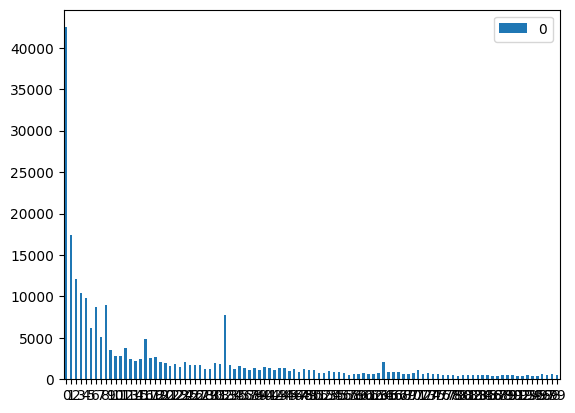

In [18]:
import pandas as pd
logic_num_group_0 = {'num_cell': logic_num_group['num_cell'][:100],
                  'num_module': logic_num_group['num_module'][:100]}
df = pd.DataFrame(logic_num_group_0['num_module'], index=logic_num_group_0['num_cell'])
# ax = df.plot.bar(x='num_cell', y='num_module', rot=0)
ax = df.plot.bar(rot=0)

In [19]:
def num_cell_segment(x):
    int_x = int(x)
    group = ''
    if x == 0:
        group = '0-0'
    else:
        for i in range(1,92, 10):
            cur_range = (i, i + 9)
            if cur_range[0] <= int_x <= cur_range[1]:
                group = f'{cur_range[0]}-{cur_range[1]}'
                break
    # print(x)
    return group
        
df_group = df.groupby(num_cell_segment, ).sum() #.rename(columns={0: 'Number of Cells'}).ren.plot.bar(rot=45,)

In [20]:
df_group = df_group.rename(index={'': '0'}).rename(columns={0: 'Number of Modules'})
df_group

,Number of Cells
0,42468
1-10,85218
11-20,27726
21-30,16752
31-40,20756
41-50,11568
51-60,7505
61-70,8587
71-80,6418
81-90,4737


In [39]:
plt.savefig('PyranetStatisticData/first_plot.pdf', format='pdf')
plt.close()

In [41]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
with PdfPages('PyranetStatisticData/first_plot.pdf') as pdf:
    plt.figure()
    # plt.bar(df_group.index, df_group['Number of Cells'])
    df_group.plot.bar(rot=45, )
    pdf.savefig()  # Save the first plot
    plt.close()    # Close the figure to free up memory


<Figure size 640x480 with 0 Axes>

## Plot all

In [44]:
# matplotlib.pyplot.subplot_mosaic
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt_subplot_mosaic = [[0, 1],
                     [2,3],
                     [4,4]]
plt.figure()
plt.subplot_mosaic(plt_subplot_mosaic, layout='constrained')
with PdfPages('PyranetStatisticData/all_plot_2.pdf') as pdf:
    # plt.bar(df_group.index, df_group['Number of Cells'])
    # df_group.plot.bar(rot=45, )
    pdf.savefig()  # Save the first plot
    plt.close()    # Close the figure to free up memory

<Figure size 640x480 with 0 Axes>

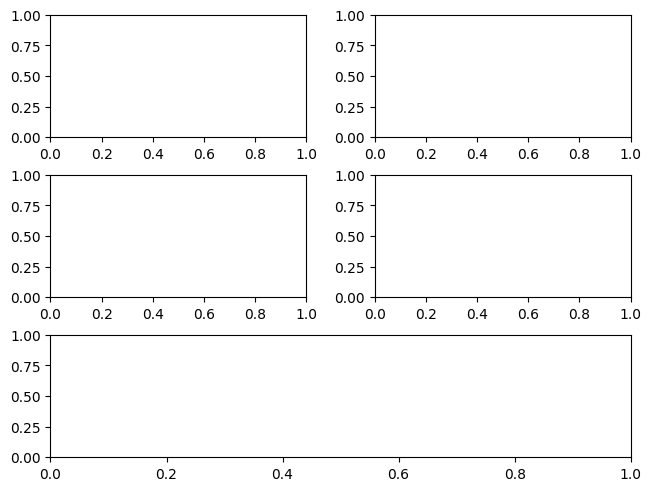

In [45]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt_subplot_mosaic = [[0, 1],
                     [2,3],
                     [4,4]]

fig, axd = plt.subplot_mosaic(plt_subplot_mosaic, layout='constrained')

In [50]:
dataset['synth_status'][300000]

111.0

In [15]:
second_index = np.array([None] * len(logic_num_group['num_cell']))

## Range 0 - 100

In [ ]:
logic_num_group

In [19]:
logic_num_group_np = np.array(logic_num_group['num_cell'])
second_index = np.array(second_index)
second_index

array([None, None, None, ..., None, None, None],
      shape=(12169,), dtype=object)

In [18]:
logic_num_group_np = logic_num_group_np.astype(np.uint64)
logic_num_group_np

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'dict_keys'

In [66]:
idx_s = np.where(logic_num_group_np == 0)[0]
second_index[idx_s] = '0-0'
second_index

array(['0-0', None, None, ..., None, None, None],
      shape=(12169,), dtype=object)

In [74]:
# idx_s = np.where(1 <= logic_num_group_np)[0]# and np.where(logic_num_group_np <= 10)[0]
# # second_index[idx_s] = '0-0'
# # second_index[idx_s]
# idx_s

array([    1,     2,     3, ..., 12166, 12167, 12168], shape=(12168,))

In [ ]:
logic_num_group['num_cell']

In [80]:
len(second_index)

12169

In [21]:
logic_num_group

{'num_cell': dict_keys(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '

In [27]:
for i in range(len(second_index)):
    int_x = int(logic_num_group['num_cell'][i])
    if int_x == 0:
        second_index[i] = '0-0'
    else:
        # 1-100, 
        # 101-1000
        # 1001-10000
        # 10001-100000
        # 100001-25000

        start_i = 100001
        stop_i = 220000
        step_i = 10000
        for ii in range(start_i,stop_i, step_i):
            cur_range = (ii, ii + step_i - 1)
            if cur_range[0] <= int_x <= cur_range[1]:
                second_index[i] = f'{cur_range[0]}-{cur_range[1]}'
                break
        # print(cur_range)
second_index

array(['0-0', '1-10', '1-10', ..., '30001-40000', '30001-40000',
       '30001-40000'], shape=(12169,), dtype=object)

In [28]:
len(np.where(second_index == None)[0])

0

In [29]:
import json
with open('PyranetStatisticData/second_index.json', 'w+') as file:
    json.dump(second_index.tolist(), file)
    # second_index.tofile()

## Multi-index

In [30]:
import pandas as pd
tuples = list(zip(*[second_index.tolist(), logic_num_group['num_cell']]))
# multi_index = pd.MultiIndex(tuples, names=["first", "second"])
# multi_index

In [31]:
multi_index = pd.MultiIndex.from_tuples(tuples, names=["Number of Cells", "second"])

In [32]:
df_2 = pd.DataFrame(logic_num_group['num_module'], index=multi_index)

In [33]:
second_index

array(['0-0', '1-10', '1-10', ..., '30001-40000', '30001-40000',
       '30001-40000'], shape=(12169,), dtype=object)

In [34]:
df_2 = df_2.rename(columns={0: 'Number of Modules'})
df_2

Number of Modules
Number of Cells second                   
0-0             0                   42468
1-10            1                   17462
                2                   12093
                3                   10438
                4                    9762
...                                   ...
30001-40000     32676                   1
60001-70000     65459                   1
30001-40000     32728                   1
                32735                   1
                32756                   1

[12169 rows x 1 columns]

## Plot all with multi index

In [186]:
df_test = pd.DataFrame({"a": [1, 2, 3, 4]}, index=['A', 'C', 'b', 'd'])
df_test.sort_index(key=lambda x: x.str.lower())

,a
A,1
b,3
C,2
d,4


In [35]:
def df_2_sort(x: pd.Index):
    # print(x.str.split('-').map(lambda y: int(y[0])))
    return x.str.split('-').map(lambda y: int(y[0]))
#     # return x[0].split('-')[0]
df_2_sorted = df_2.sort_index(key=df_2_sort)

In [36]:
df_2_sorted

Number of Modules
Number of Cells second                   
0-0             0                   42468
1-10            1                   17462
                2                   12093
                3                   10438
                4                    9762
...                                   ...
210001-220000   213045                  1
                216445                  1
                216495                  1
                217556                  1
                217596                  1

[12169 rows x 1 columns]

In [37]:
df_2_sorted.index

MultiIndex([(          '0-0',      '0'),
            (         '1-10',      '1'),
            (         '1-10',      '2'),
            (         '1-10',      '3'),
            (         '1-10',      '4'),
            (         '1-10',      '5'),
            (         '1-10',      '6'),
            (         '1-10',      '7'),
            (         '1-10',      '8'),
            (         '1-10',      '9'),
            ...
            ('170001-180000', '177359'),
            ('170001-180000', '177486'),
            ('180001-190000', '187604'),
            ('190001-200000', '192420'),
            ('200001-210000', '204706'),
            ('210001-220000', '213045'),
            ('210001-220000', '216445'),
            ('210001-220000', '216495'),
            ('210001-220000', '217556'),
            ('210001-220000', '217596')],
           names=['Number of Cells', 'second'], length=12169)

In [38]:
df_2_sorted_group = df_2_sorted.groupby(level=0).sum()

In [39]:
df_2_sorted_group

,Number of Modules
Number of Cells,
0-0,42468
1-10,85218
100001-110000,641
10001-20000,2879
1001-2000,9508
101-200,34621
11-20,27726
110001-120000,158
120001-130000,20


In [40]:
df_2_sorted_group_sorted = df_2_sorted_group.sort_index(key=lambda x: x.str.split('-').map(lambda y: int(y[0])))
df_2_sorted_group_sorted

,Number of Modules
Number of Cells,
0-0,42468
1-10,85218
11-20,27726
21-30,16752
31-40,20756
41-50,11568
51-60,7505
61-70,8587
71-80,6418


In [ ]:
df_2_sorted_group_sorted = df_2_sorted_group_sorted.rename_axis(index={'first': 'Number of Cells'})
df_2_sorted_group_sorted

In [137]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pandas.plotting import table

plt_subplot_mosaic = [[0, 0],
                     [1,2],
                     [3,4]]
plt.figure()
fig, axd = plt.subplot_mosaic(plt_subplot_mosaic, layout='constrained')

df_ranges = [('0-0', '91-100'), 
             ('101-200', '901-1000'), 
             ('1001-2000', '9001-10000'),
             ('10001-20000', '90001-100000'),
             ('100001-110000', None),
            ]
with PdfPages('PyranetStatisticData/all_plot_final_1.pdf') as pdf:
    
    for i in range(len(df_ranges)):
        df_range = df_ranges[i]
        df_plot: pd.DataFrame = df_2_sorted_group_sorted.loc[df_range[0]:df_range[1]]
        df_plot = df_plot.astype(np.uint64)
        
        #
        
        rot = 22.5

        df_plot_total = pd.DataFrame(df_plot.sum()).rename(index={'Number of Modules': 'total'}, columns={0: 'Number of Modules'})
        df_plot_statistic = df_plot.describe().loc[['min', 'max']]
        
        
        df_plot_statistic = pd.concat([df_plot_statistic, df_plot_total]).astype(np.uint64)
        
        colWidths = [1/4, 1/4] if i == 0 else [1/2, 1/2]
        df_plot.plot.bar(rot=rot, ax=axd[i], figsize=(10, 10), legend=None)
        print(df_plot_statistic)
        cur_table = table(axd[i], df_plot_statistic, loc="upper right", colWidths=colWidths)
        
        
    pdf.savefig()  # Save the first plot
    plt.close()    # Close the figure to free up memory
# 

       Number of Modules
min                 4737
max                85218
total             236560
       Number of Modules
min                 1626
max                34621
total              81336
       Number of Modules
min                  642
max                 9508
total              26302
       Number of Modules
min                   36
max                 2879
total               6328
       Number of Modules
min                    1
max                  641
total                903


<Figure size 640x480 with 0 Axes>

In [118]:
[1, 2, 3] * 2

[1, 2, 3, 1, 2, 3]

# Explore instantiation number

min_ins_num = [len(dataset['module_definition'][0]), 0]
max_ins_num = [len(dataset['module_definition'][0]), 0]
len_dict = {}
for i in range(1, len(dataset)):
    len_module_definition = len(dataset['module_definition'][i])
    if len_module_definition < min_ins_num[0]:
        min_ins_num[0] = len_module_definition
    if len_module_definition > max_ins_num[0]:
        max_ins_num[0] = len_module_definition

    len_module_definition = str(len_module_definition)
    if len_module_definition not in len_dict:
        len_dict[len_module_definition] = []
    len_dict[len_module_definition].append(i)
    
(min_ins_num, max_ins_num)

In [ ]:
len(len_dict)

In [ ]:
lens = [int(x) for x in list(len_dict.keys())]

In [ ]:
lens.sort()
lens

In [ ]:
import json
with open('PyranetStatisticData/num_ins_dictionary.json', 'w+') as file:
    json.dump(len_dict, file)


In [ ]:
print(dataset['code'][111111])

In [ ]:
print(dataset['code'][4304])

In [ ]:
len_dict['2'][10]

## Bar charts

In [ ]:
!pip install pandas matplotlib

In [ ]:
import pandas as pd

In [ ]:
ins_num = [int(x) for x in list(len_dict.keys())]
ins_num.sort()
module_num = [len(len_dict[str(x)]) for x in ins_num]

In [ ]:
len_dict['1'][10]

In [ ]:
len(len_dict)

In [ ]:
# ins_num = [int(x) for x in list(len_dict.keys())]
# ins_num.sort()
# module_num = [len_dict[str(x)] for x in ins_num]
a_df = pd.DataFrame({'ins_num': ins_num, 'module_num': module_num})
ax = a_df[:10].plot.bar(x='ins_num', y='module_num', rot=0)

In [ ]:
len(len_dict)

In [ ]:
a_df['module_num']

In [ ]:
ax2 = a_df[2:].plot.bar(x='ins_num', y='module_num', rot=0)